# Quantum_FL_RS_general_Ne_Nx

Clean generalized notebook for comparing the many-body Qiskit evolution with the Raffelt--Sigl mean-field evolution for

\[
N_e\;\nu_e + N_x\;\nu_x(\alpha),
\qquad
\nu_x(\alpha)=\cos\alpha\,\nu_e+\sin\alpha\,\nu_\mu .
\]

This is the generalized version of the older fixed \(1\nu_e+15\nu_x\) notebook.

Default choice:

\[
N_e=1,\qquad N_x=15.
\]

To check \(N_e=2\) later, change only `Ne` in Cell 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integ

from scipy.special import gammaln
from sympy.physics.wigner import clebsch_gordan
from sympy import S as sympy_S

from concurrent.futures import ProcessPoolExecutor
import os

In [2]:
import argparse

parser = argparse.ArgumentParser(
    description="Raffelt-Sigl vs analytical neutrino oscillation calculation"
)

parser.add_argument(
    "--Ne",
    type=int,
    required=True,
    help="Number of initially electron-flavor neutrinos",
)

parser.add_argument(
    "--Nx",
    type=int,
    required=True,
    help="Number of initially x-flavor neutrinos",
)

args = parser.parse_args()

Ne = args.Ne
Nx = args.Nx

N = Ne + Nx

if Ne < 1 or Nx < 1:
    raise ValueError("Ne and Nx must be positive integers.")

Enter the number of electron-flavor neutrinos (Ne):  1
Enter the number of x-flavor neutrinos (Nx):  10


In [3]:
# =============================
# CELL 1: Imports and parameters
# =============================

# -----------------------------
# Physics parameters
# -----------------------------
E = 1.0
dm2 = 1.0
theta_vac = 0.195

sin_2th = np.sin(2.0 * theta_vac)
cos_2th = np.cos(2.0 * theta_vac)
omega1 = dm2 / (4.0 * E)

bx = omega1 * np.sin(2.0 * theta_vac)
by = 0.0
bz = -omega1 * np.cos(2.0 * theta_vac)

# This is the scale used for the dimensionless time axis t*mu.
mu = 1

# -----------------------------
# Evolution choices
# -----------------------------
# Self-interaction only
use_vacuum = False
use_matter = False

# -----------------------------
# Time parameters
# -----------------------------
dt = 0.01
T_max = 10.0
sample_every = 10

n_steps_max = int(round(T_max / dt))
times = np.arange(
    0,
    n_steps_max + 1,
    sample_every
) * dt

# -----------------------------
# Alpha cases
# -----------------------------
alpha_cases = [
    (np.pi/2, r"\pi/2"),
    (np.pi/3, r"\pi/3"),
    (np.pi/4, r"\pi/4"),
    (np.pi/6, r"\pi/6"),
    (0.0,     r"0"),
]

# -----------------------------
# SLURM CPU information
# -----------------------------
n_workers = int(
    os.environ.get(
        "SLURM_CPUS_PER_TASK",
        os.cpu_count()
    )
)

print(f"Using Ne = {Ne}, Nx = {Nx}, total N = {N}")
print(f"omega1 = {omega1}")
print(f"mu = omega1 * N = {mu}")
print(
    f"Number of sampled times = {len(times)}, "
    f"T_max = {T_max}, dt = {dt}"
)
print(
    f"Evolution mode: self-interaction only = "
    f"{not use_vacuum and not use_matter}"
)
print(f"Parallel workers = {n_workers}")

Using Ne = 1, Nx = 10, total N = 11
omega1 = 0.25
mu = omega1 * N = 1
Number of sampled times = 101, T_max = 10, dt = 0.01
Evolution mode: self-interaction only = True


In [4]:
# =======================================
# CELL 2: Interaction matrix J_ij
# =======================================



#J = interaction_matrix(N, dm2, E)
J=1
#print("J shape =", J.shape)
#print("J min/max =", J.min(), J.max())

In [6]:
# ============================================
# CELL 4: Raffelt--Sigl mean-field solver
# ============================================

# Pauli matrices
sigma_0 = np.array([[1, 0],  [0,  1]], dtype=complex)
sigma_1 = np.array([[0, 1],  [1,  0]], dtype=complex)
sigma_2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_3 = np.array([[1, 0],  [0, -1]], dtype=complex)


def P_osc_RS(t_table, theta, omega, lam, J, initial_flavors=None, alpha=None):
    """
    Raffelt--Sigl two-flavor polarization-vector evolution.

    Parameters
    ----------
    t_table : array
        Sampled times.
    theta : float
        Vacuum mixing angle.
    omega : array
        Vacuum frequencies for all modes.
    lam : float
        Matter strength.
    J : array
        Coupling matrix.
    initial_flavors : array
        Entries may be:
            'e'  : |nu_e>
            'x'  : |nu_mu>
            'mu' : |nu_mu>
            'a'  : cos(alpha)|nu_e> + sin(alpha)|nu_mu>
    alpha : float
        Superposition angle for every mode labeled 'a'.
    """
    n_modes = omega.size

    u = np.array([[np.cos(theta), np.sin(theta)],
                  [-np.sin(theta), np.cos(theta)]])
    b = 0.5 * np.diag([-1, 1])
    b = u @ b @ u.T
    l = np.diag([1, 0])

    Ee = np.array([0.0, 0.0,  1.0])
    Emu = np.array([0.0, 0.0, -1.0])

    B = np.real(np.array([np.trace(b @ sigma_1),
                          np.trace(b @ sigma_2),
                          np.trace(b @ sigma_3)]))
    L = np.real(np.array([np.trace(l @ sigma_1),
                          np.trace(l @ sigma_2),
                          np.trace(l @ sigma_3)]))

    ini_state = np.where(omega > 0, Ee[:, None], Emu[:, None])

    if initial_flavors is not None:
        initial_flavors = np.asarray(initial_flavors)

        for f in initial_flavors:
            if f not in ["e", "x", "mu", "a"]:
                raise ValueError(f"Unknown flavor label: {f}")
            if f == "a" and alpha is None:
                raise ValueError("Flavor label 'a' requires alpha.")

        ini_state[:, initial_flavors == "e"] = Ee[:, None]
        ini_state[:, initial_flavors == "x"] = Emu[:, None]
        ini_state[:, initial_flavors == "mu"] = Emu[:, None]
        ini_state[:, initial_flavors == "a"] = np.array(
            [np.sin(2.0 * alpha), 0.0, np.cos(2.0 * alpha)]
        )[:, None]

    def rhs(t, P_flat):
        """
        dP_k/dt = H_k x P_k,
        H_k = omega_k B + lambda L + sum_j J_kj P_j.
        """
        res = np.zeros(3 * n_modes)
        PP = np.reshape(P_flat, (n_modes, 3)).T
        
        for k in range(n_modes):
            H_k = omega[k] * B + lam * L + J * np.sum(PP, axis=1)
            res[3*k:3*k+3] = np.cross(H_k, PP[:, k])

        return res
    
   # return integ.solve_ivp(
   #     rhs,
   #     (t_table[0], t_table[-1]),
   #     ini_state.T.flatten(),
   #     t_eval=t_table,
   # )
    return integ.solve_ivp(
        rhs,
        (t_table[0], t_table[-1]),
        ini_state.T.flatten(),
        t_eval=t_table,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
    )

In [8]:
# =====================================================
# CELL 6: RS solver and combined alpha-case runner
# =====================================================

def run_rs_mean_field(alpha, Ne, Nx, J, times,
                      use_vacuum=False, use_matter=False):
    """
    Run the Raffelt--Sigl mean-field evolution for the same initial state.

    Default:
        omega = 0,
        lambda = 0,

    so this solves the self-interaction-only mean-field problem, matching
    the old e1_x15 comparison.
    """
    N = Ne + Nx

    if use_vacuum:
        omega = np.ones(N) * omega1
        theta_rs = theta_vac
    else:
        omega = np.zeros(N)
        theta_rs = 0.0

    lam = 1.0 if use_matter else 0.0

    initial_flavors = np.array(["e"] * Ne + ["a"] * Nx)

    sol = P_osc_RS(
        times,
        theta_rs,
        omega,
        lam,
        J,
        initial_flavors=initial_flavors,
        alpha=alpha,
    )

    P_all = sol.y
    P = P_all.reshape(N, 3, -1)
    Pz = P[:, 2, :]

    # P(nu_mu) = (1 - Pz)/2 for each mode.
    P_mu = 0.5 * (1.0 - Pz)

    return {
        "sol": sol,
        "P": P,
        "Pz": Pz,
        "P_mu": P_mu,
        "P_e_to_mu_avg": np.mean(P_mu[:Ne, :], axis=0),
    }




## Figures for different \(\alpha\)

Each cell below runs one \(\alpha\) case and produces one figure.

The plotted observable is the average conversion probability of the initially electron-flavor group:

\[
\left\langle P(\nu_e\rightarrow \nu_\mu)\right\rangle_{N_e}.
\]

In [11]:
import numpy as np
from scipy.special import gammaln
from sympy.physics.wigner import clebsch_gordan
from sympy import S as sympy_S


def cg_coefficient(j1, m1, j2, m2, J, M):
    """
    Clebsch-Gordan coefficient

        <j1,m1; j2,m2 | J,M>

    using the SymPy convention.
    """
    return float(
        clebsch_gordan(
            sympy_S(j1),
            sympy_S(j2),
            sympy_S(J),
            sympy_S(m1),
            sympy_S(m2),
            sympy_S(M)
        )
    )


def collective_oscillation_probability(
    N1,
    N2,
    alpha,
    t,
    lam=1.0,
    large_N_correction=True,
    N1_threshold=10,
    N2_threshold=10,
    sector_cutoff=1e-10
):
    """
    Collective nu_e -> nu_mu oscillation probability for a two-beam system.

    The function distinguishes between:

        1. The efficient pure-nu_mu approximation for alpha = pi/2
           when the system is not in the large-N regime.

        2. The full sector sum when large-N effects are relevant.

    Parameters
    ----------
    N1 : int
        Number of initial nu_e neutrinos in beam 1.

    N2 : int
        Number of neutrinos in beam 2.

    alpha : float
        Mixing angle appearing in

            |x> = cos(alpha)|e> + sin(alpha)|mu>.

    t : float or array-like
        Evolution time.

    lam : float, optional
        Interaction strength lambda.

    large_N_correction : bool, optional
        If True, activate the large-N treatment.

    N1_threshold : int, optional
        N1 above which the large-N treatment is activated.

    N2_threshold : int, optional
        N2 above which the large-N treatment is activated.

    sector_cutoff : float, optional
        Binomial sectors whose relative weight is smaller than this
        are neglected in the large-N calculation.

    Returns
    -------
    P_emu : float or ndarray
        Conversion probability for one neutrino in beam 1.
    """

    # ============================================================
    # Input checks
    # ============================================================

    if not isinstance(N1, (int, np.integer)):
        raise TypeError("N1 must be an integer.")

    if not isinstance(N2, (int, np.integer)):
        raise TypeError("N2 must be an integer.")

    if N1 < 1 or N2 < 1:
        raise ValueError("N1 and N2 must be positive integers.")

    # ============================================================
    # Spin quantum numbers
    # ============================================================

    j1 = N1 / 2
    j2 = N2 / 2

    Jmax = j1 + j2

    # ============================================================
    # Time array
    # ============================================================

    t = np.asarray(t, dtype=float)

    Nmu = np.zeros_like(t, dtype=float)

    # ============================================================
    # Mixing probabilities
    # ============================================================

    c = np.cos(alpha)
    s = np.sin(alpha)

    p_e = c**2
    p_mu = s**2

    # Remove tiny floating-point excursions
    p_e = np.clip(p_e, 0.0, 1.0)
    p_mu = np.clip(p_mu, 0.0, 1.0)

    # ============================================================
    # Determine whether we are at the exact endpoint
    # ============================================================

    alpha_is_exact_pi_over_2 = (
        alpha == np.pi / 2
    )

    # ============================================================
    # Large-N physics indicator
    #
    # For alpha close to pi/2, the relevant parameter is
    #
    #       N2 * cot^2(alpha)
    #
    # because
    #
    #   W_{N2-1}/W_{N2}
    #       = N2 cot^2(alpha).
    #
    # Large N1 is also treated as a collective regime because
    # the number of allowed conversion channels j grows with N1.
    # ============================================================

    if p_mu > 0:
        large_N_parameter = N2 * p_e / p_mu
    else:
        large_N_parameter = 0.0

    large_N_system = (
        large_N_correction
        and (
            N1 >= N1_threshold
            or N2 >= N2_threshold
            or large_N_parameter >= 0.01
        )
    )

    # ============================================================
    # SPECIAL CASE:
    #
    # EXACT alpha = pi/2 AND NOT large-N
    #
    # Here |x> = |mu> exactly and only i=N2 contributes.
    #
    # This retains your original fast calculation.
    # ============================================================

    if alpha_is_exact_pi_over_2 and not large_N_system:

        i = N2

        M = Jmax - i

        Smin = max(
            M,
            abs(j1 - j2)
        )

        for j in range(1, min(i, N1) + 1):

            m1_initial = j1
            m2_initial = j2 - i

            m1_final = j1 - j
            m2_final = j2 - i + j

            real_part = np.zeros_like(t, dtype=float)
            imag_part = np.zeros_like(t, dtype=float)

            S_values = np.arange(
                Smin,
                Jmax + 1,
                1
            )

            for Stotal in S_values:

                C_initial = cg_coefficient(
                    j1,
                    m1_initial,
                    j2,
                    m2_initial,
                    Stotal,
                    M
                )

                C_final = cg_coefficient(
                    j1,
                    m1_final,
                    j2,
                    m2_final,
                    Stotal,
                    M
                )

                coefficient = C_initial * C_final

                E_S = 2 * lam * Stotal * (Stotal + 1)

                real_part += (
                    coefficient * np.cos(E_S * t)
                )

                imag_part -= (
                    coefficient * np.sin(E_S * t)
                )

            P_ij = real_part**2 + imag_part**2

            Nmu += j * P_ij

        return Nmu / N1

    # ============================================================
    # DETERMINE WHICH i-SECTORS TO CALCULATE
    # ============================================================

    if large_N_system:

        # --------------------------------------------------------
        # Large-N calculation
        #
        # Define
        #
        #       k = N2 - i
        #
        # where k is the number of nu_e components in beam 2.
        #
        # The binomial distribution is concentrated around
        #
        #       k ~ N2 cos^2(alpha).
        # --------------------------------------------------------

        mean_k = N2 * p_e

        sigma_k = np.sqrt(
            N2 * p_e * p_mu
        )

        # --------------------------------------------------------
        # If alpha is extremely close to pi/2, the distribution
        # is concentrated near k=0. Otherwise it can be centered
        # at a nonzero k.
        #
        # Keep several standard deviations around the peak.
        # --------------------------------------------------------

        k_center = int(round(mean_k))

        k_min = max(
            0,
            int(np.floor(mean_k - 8.0 * sigma_k))
        )

        k_max = min(
            N2,
            int(np.ceil(mean_k + 8.0 * sigma_k))
        )

        # Make sure the pure nu_mu sector is included whenever
        # it has nonzero weight.
        k_min = 0

        i_values = [
            N2 - k
            for k in range(k_min, k_max + 1)
        ]

    else:

        # --------------------------------------------------------
        # Ordinary general calculation
        # --------------------------------------------------------

        i_values = range(1, N2 + 1)

    # ============================================================
    # MAIN SECTOR SUM
    # ============================================================

    for i in i_values:

        # --------------------------------------------------------
        # The i=0 sector cannot produce nu_mu neutrinos in beam 1.
        # --------------------------------------------------------

        if i == 0:
            continue

        # --------------------------------------------------------
        # Binomial weight
        #
        #       W_i =
        #       C(N2,i)
        #       (cos^2 alpha)^(N2-i)
        #       (sin^2 alpha)^i
        #
        # Use logarithms for numerical stability.
        # --------------------------------------------------------

        if p_e == 0.0:

            # Exact pure-nu_mu beam-2 state
            if i != N2:
                continue

            weight = 1.0

        elif p_mu == 0.0:

            # Pure nu_e beam-2 state
            if i != 0:
                continue

            weight = 1.0

        else:

            log_weight = (
                gammaln(N2 + 1)
                - gammaln(i + 1)
                - gammaln(N2 - i + 1)
                + (N2 - i) * np.log(p_e)
                + i * np.log(p_mu)
            )

            weight = np.exp(log_weight)

        # --------------------------------------------------------
        # Ignore numerically irrelevant sectors.
        #
        # The relative criterion is used only in the large-N
        # calculation.
        # --------------------------------------------------------

        if large_N_system and weight < sector_cutoff:
            continue

        # --------------------------------------------------------
        # Total magnetic quantum number
        # --------------------------------------------------------

        M = Jmax - i

        # --------------------------------------------------------
        # Allowed total-spin range
        # --------------------------------------------------------

        Smin = max(
            M,
            abs(j1 - j2)
        )

        S_values = np.arange(
            Smin,
            Jmax + 1,
            1
        )

        # --------------------------------------------------------
        # Number of possible conversions in beam 1
        # --------------------------------------------------------

        for j in range(
            1,
            min(i, N1) + 1
        ):

            # Initial product state

            m1_initial = j1
            m2_initial = j2 - i

            # Final product state

            m1_final = j1 - j
            m2_final = j2 - i + j

            # ----------------------------------------------------
            # Transition amplitude
            # ----------------------------------------------------

            real_part = np.zeros_like(
                t,
                dtype=float
            )

            imag_part = np.zeros_like(
                t,
                dtype=float
            )

            # ----------------------------------------------------
            # Sum over total spin S
            # ----------------------------------------------------

            for Stotal in S_values:

                C_initial = cg_coefficient(
                    j1,
                    m1_initial,
                    j2,
                    m2_initial,
                    Stotal,
                    M
                )

                C_final = cg_coefficient(
                    j1,
                    m1_final,
                    j2,
                    m2_final,
                    Stotal,
                    M
                )

                coefficient = (
                    C_initial * C_final
                )

                # Energy eigenvalue

                E_S = (
                    2 * lam
                    * Stotal
                    * (Stotal + 1)
                )

                # e^{-i E_S t}

                real_part += (
                    coefficient
                    * np.cos(E_S * t)
                )

                imag_part -= (
                    coefficient
                    * np.sin(E_S * t)
                )

            # ----------------------------------------------------
            # Transition probability
            # ----------------------------------------------------

            P_ij = (
                real_part**2
                + imag_part**2
            )

            # ----------------------------------------------------
            # Contribution to <N_mu>
            # ----------------------------------------------------

            Nmu += (
                weight
                * j
                * P_ij
            )

    # ============================================================
    # Probability for one neutrino in beam 1
    # ============================================================

    return Nmu / N1

In [12]:
def calculate_one_time_point(args):

    alpha, t = args

    # -------------------------------------------------
    # RS mean-field
    # -------------------------------------------------

    if t == 0.0:

        P_rs = 0.0

    else:

        result_rs = run_rs_mean_field(
            alpha=alpha,
            Ne=Ne,
            Nx=Nx,
            J=J,
            times=np.array([0.0, t]),
            use_vacuum=use_vacuum,
            use_matter=use_matter,
        )

        P_rs = result_rs["P_e_to_mu_avg"][-1]

    # -------------------------------------------------
    # Analytical result
    # -------------------------------------------------

    P_analytic = collective_oscillation_probability(
        N1=Ne,
        N2=Nx,
        alpha=alpha,
        t=t,
        lam=J,
    )

    return t, P_rs, float(P_analytic)


Calculating alpha = \pi/2


Process SpawnProcess-2:
Traceback (most recent call last):
Process SpawnProcess-1:
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.0_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/opt/homebrew/Cellar/python@3.13/3.13.0_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/homebrew/Cellar/python@3.13/3.13.0_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/concurrent/futures/process.py", line 241, in _process_worker
    call_item = call_queue.get(block=True)
  File "/opt/homebrew/Cellar/python@3.13/3.13.0_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py", line 120, in get
    return _ForkingPickler.loads(res)
           ~~~~~~~~~~~~~~~~~~~~~^^^^^
Attribut

BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

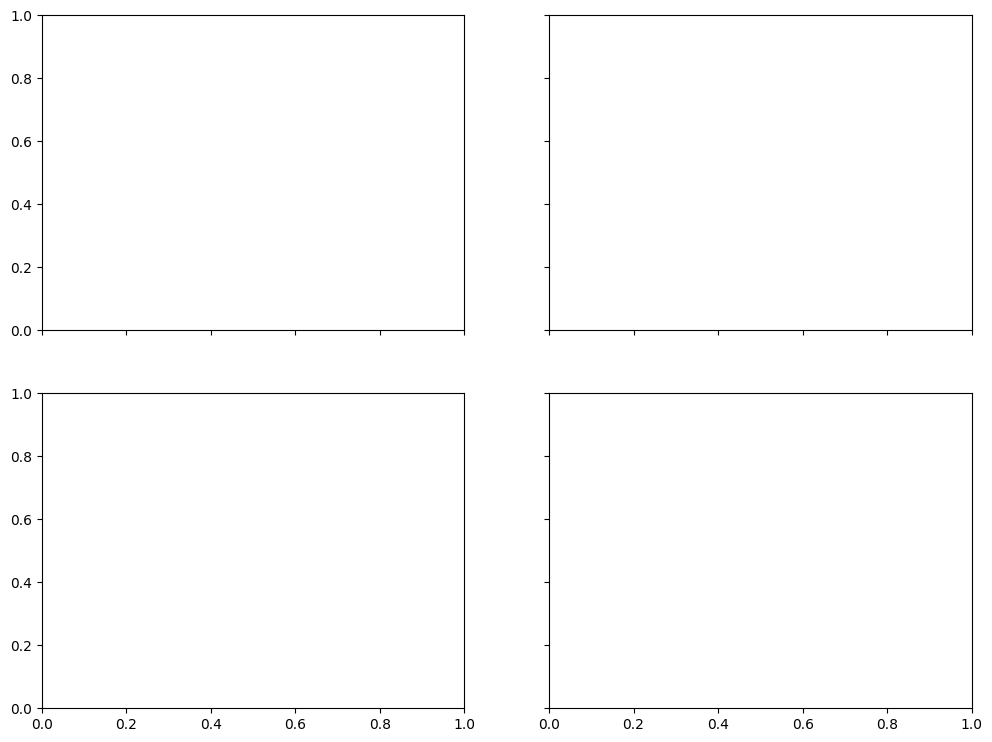

In [13]:
# =====================================================
# CELL 7: Compare RS mean field with analytical result
#
# SLURM ARRAY VERSION
#
# 25 SLURM array tasks
# 4 CPUs per task
# 4 Python workers per task
#
# Each SLURM task handles its assigned time points.
# The time points within each task are calculated
# in parallel using ProcessPoolExecutor.
#
# Results are saved as CSV files in:
#     output/
#
# The filename contains the time range handled by
# that SLURM task.
# =====================================================

if __name__ == "__main__":

    import pandas as pd

    # -------------------------------------------------
    # Alpha cases
    # -------------------------------------------------

    alpha_cases = [
        (np.pi/2, r"\pi/2"),
        (np.pi/3, r"\pi/3"),
        (np.pi/4, r"\pi/4"),
        (np.pi/6, r"\pi/6"),
    ]

    # -------------------------------------------------
    # SLURM array information
    # -------------------------------------------------

    array_id = int(
        os.environ["SLURM_ARRAY_TASK_ID"]
    )

    n_array_tasks = 25

    # -------------------------------------------------
    # Divide the complete time array among the
    # 25 SLURM array tasks
    #
    # Example for 101 time points:
    #
    # Task 0  -> first 5 points
    # Task 1  -> next 4 points
    # ...
    # Task 24 -> last 4 points
    #
    # This gives 101 points in total.
    # -------------------------------------------------

    n_times_total = len(times)

    base = n_times_total // n_array_tasks
    remainder = n_times_total % n_array_tasks

    if array_id < remainder:

        start = array_id * (base + 1)
        end = start + (base + 1)

    else:

        start = (
            remainder * (base + 1)
            + (array_id - remainder) * base
        )

        end = start + base

    my_times = times[start:end]

    # -------------------------------------------------
    # Safety check
    # -------------------------------------------------

    if len(my_times) == 0:
        raise RuntimeError(
            f"SLURM array task {array_id} "
            f"received no time points."
        )

    print(
        "\n=============================================="
    )

    print(
        f"SLURM array task = {array_id}"
    )

    print(
        f"Total time points = {n_times_total}"
    )

    print(
        f"Time indices = {start} ... {end - 1}"
    )

    print(
        f"Number of assigned time points = "
        f"{len(my_times)}"
    )

    print(
        f"Time range = "
        f"{my_times[0]:.1f} ... {my_times[-1]:.1f}"
    )

    print(
        "=============================================="
    )

    # -------------------------------------------------
    # Store results
    # -------------------------------------------------

    rows = []

    # -------------------------------------------------
    # Loop over alpha sequentially
    # -------------------------------------------------

    for alpha, alpha_label in alpha_cases:

        print(
            f"\nTask {array_id}: "
            f"Calculating alpha = {alpha_label}"
        )

        # -------------------------------------------------
        # One calculation job per time point
        # -------------------------------------------------

        jobs = [
            (alpha, float(t))
            for t in my_times
        ]

        # -------------------------------------------------
        # Four Python workers inside this SLURM task
        #
        # Therefore:
        #
        # 25 SLURM tasks x 4 Python workers
        # = up to 100 simultaneous calculations
        # -------------------------------------------------

        with ProcessPoolExecutor(
            max_workers=4
        ) as executor:

            output = list(
                executor.map(
                    calculate_one_time_point,
                    jobs
                )
            )

        # -------------------------------------------------
        # Restore time ordering
        # -------------------------------------------------

        output.sort(
            key=lambda x: x[0]
        )

        # -------------------------------------------------
        # Store results in rows
        # -------------------------------------------------

        for t, P_rs_value, P_analytic_value in output:

            rows.append(
                {
                    "time": t,
                    "alpha": alpha,
                    "P_RS": P_rs_value,
                    "P_analytic": P_analytic_value,
                }
            )

    # -----------------------------------------------------
    # Convert results to DataFrame
    # -----------------------------------------------------

    df = pd.DataFrame(
        rows,
        columns=[
            "time",
            "alpha",
            "P_RS",
            "P_analytic",
        ]
    )

    # -----------------------------------------------------
    # Sort by alpha and time
    # -----------------------------------------------------

    df.sort_values(
        by=["alpha", "time"],
        inplace=True
    )

    # -----------------------------------------------------
    # Create output directory
    # -----------------------------------------------------

    output_dir = "output"

    os.makedirs(
        output_dir,
        exist_ok=True
    )

    # -----------------------------------------------------
    # Filename based on actual time range
    # -----------------------------------------------------

    t_start = my_times[0]
    t_end = my_times[-1]

    output_filename = os.path.join(
        output_dir,
        f"Analytic_vsRS_Ne{Ne}_Nx{Nx}"
        f"_t{t_start:.1f}-{t_end:.1f}.csv"
    )

    # -----------------------------------------------------
    # Save CSV
    # -----------------------------------------------------

    df.to_csv(
        output_filename,
        index=False
    )

    # -----------------------------------------------------
    # Print summary
    # -----------------------------------------------------

    print(
        "\n=============================================="
    )

    print(
        f"Task {array_id} completed."
    )

    print(
        f"Time range = "
        f"{t_start:.1f} to {t_end:.1f}"
    )

    print(
        f"Rows written = {len(df)}"
    )

    print(
        f"Results saved to:"
    )

    print(
        output_filename
    )

    print(
        "=============================================="
    )

# 